In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [13]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format

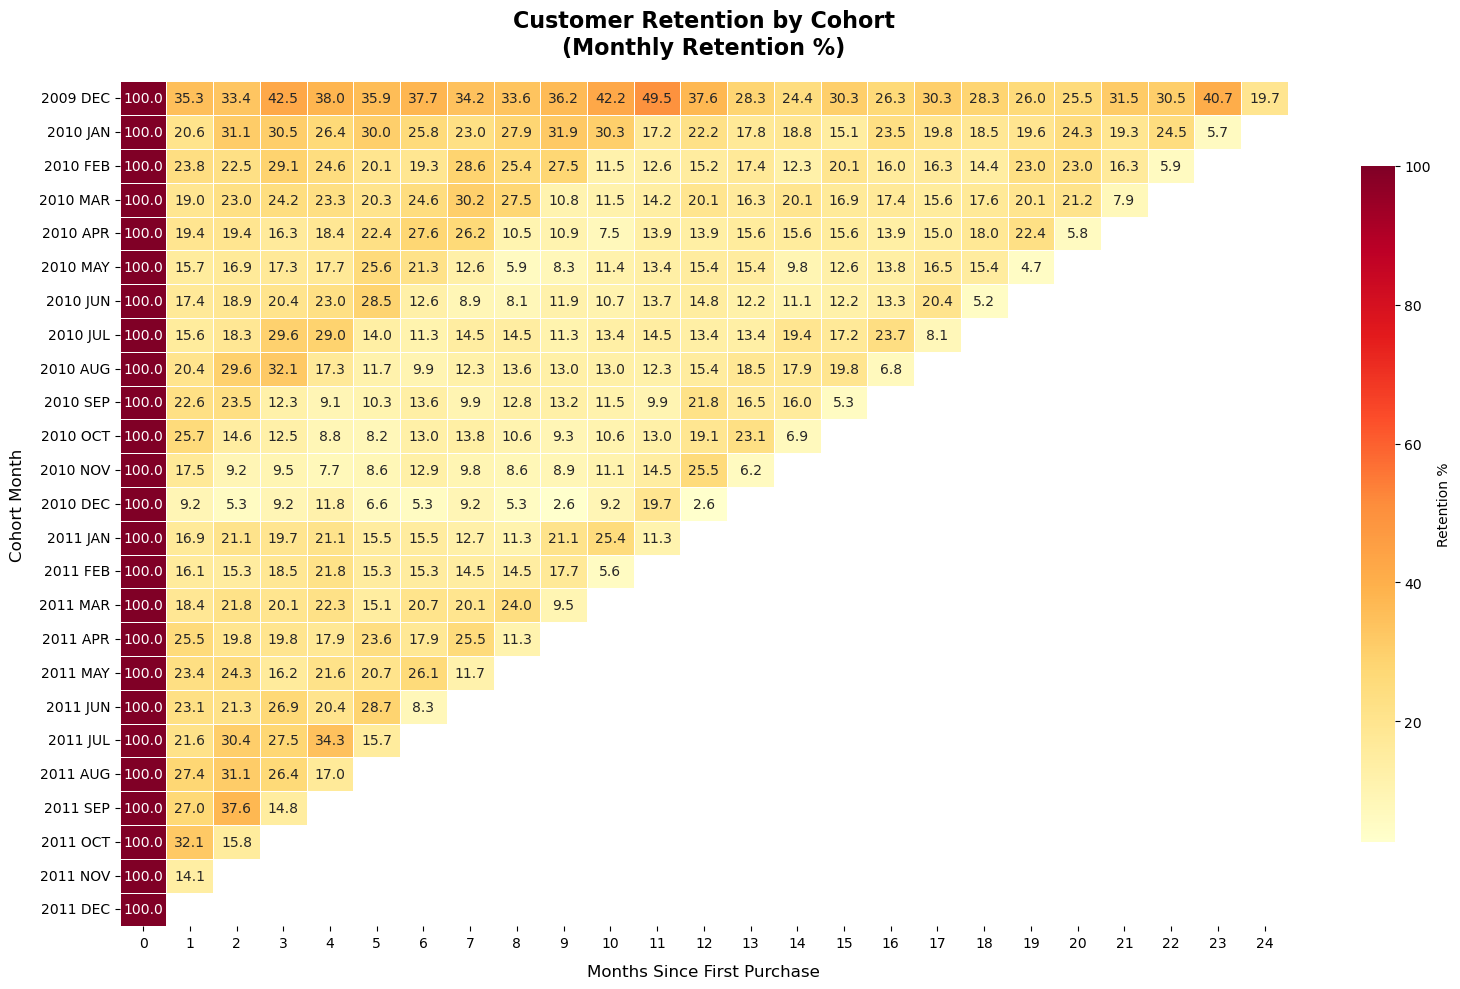

In [2]:
# --- Load ---
cohort_df = pd.read_csv('data/cohort_analysis_pct.csv')

# --- Convert and sort BEFORE pivot ---
cohort_df['cohort_month'] = pd.to_datetime(cohort_df['cohort_month'])
cohort_df = cohort_df.sort_values('cohort_month')

# --- Create formatted labels in correct order ---
cohort_df['cohort_label'] = cohort_df['cohort_month'].dt.strftime('%Y %b').str.upper()

# --- Pivot using the formatted label ---
cohort_matrix = cohort_df.pivot_table(
    index='cohort_label',
    columns='month_number',
    values='retention_pct'
)

# --- Reindex to preserve chronological order ---
ordered_labels = cohort_df['cohort_label'].drop_duplicates().tolist()
cohort_matrix = cohort_matrix.reindex(ordered_labels)

# --- Plot (same as before) ---
fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    cohort_matrix,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Retention %', 'shrink': 0.8}
)

ax.set_title('Customer Retention by Cohort\n(Monthly Retention %)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Months Since First Purchase', fontsize=12, labelpad=10)
ax.set_ylabel('Cohort Month', fontsize=12, labelpad=10)

plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# filtered_table_10=revenue_df[(revenue_df['revenue_month'].dt.year!=2011) & (revenue_df['revenue_month'].dt.year!=2009)]
# filtered_table_10.describe()


# filtered_table_11=revenue_df[(revenue_df['revenue_month'].dt.year!=2010) & (revenue_df['revenue_month'].dt.year!=2009)]
# filtered_table_11.describe()
# # mean_10 = 726505.25
# # mean_11 = 694892.67

#  # Count months where revenue is greater than or equal to the yearly mean
#  num_months_10 = len(filtered_table_10[filtered_table_10['total_revenue'] >= mean_10])
#  num_months_11 = len(filtered_table_11[filtered_table_11['total_revenue'] >= mean_11])

#  Improved print statement for clarity
#  print(f"In 2010, {num_months_10} months exceeded the mean revenue of {mean_10:,.2f}")
#  print(f"In 2011, {num_months_11} months exceeded the mean revenue of {mean_11:,.2f}")


# country_df


,country,total_revenue,unique_customers,total_orders,avg_order_value
0,United Kingdom,14723147.52,5350,33541,438.96
1,EIRE,621631.11,5,567,1096.35
2,Netherlands,554232.34,22,228,2430.84
3,Germany,431262.46,107,789,546.59
4,France,355257.47,95,614,578.60
5,Australia,169968.11,15,95,1789.14
6,Spain,109178.53,41,154,708.95
7,Switzerland,100365.34,22,90,1115.17
8,Sweden,91549.72,19,104,880.29
9,Denmark,69862.19,12,43,1624.70


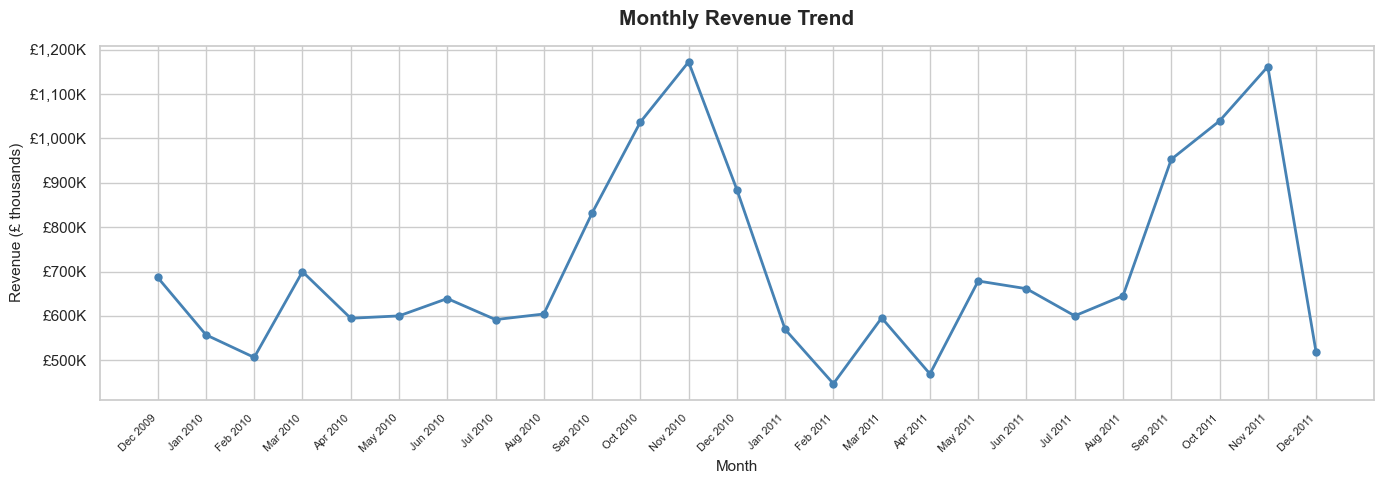

Chart 1 saved.


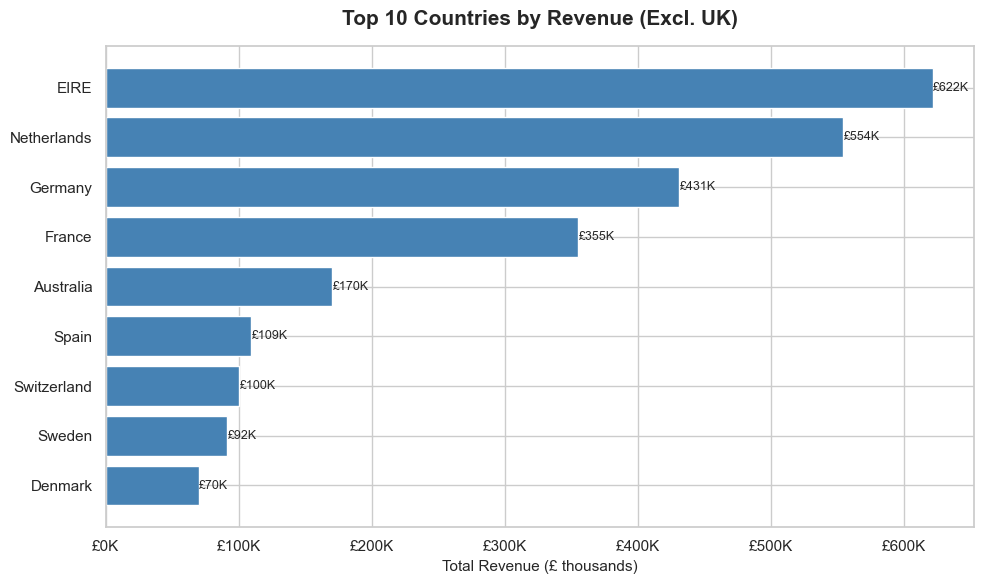

Chart 2 saved.


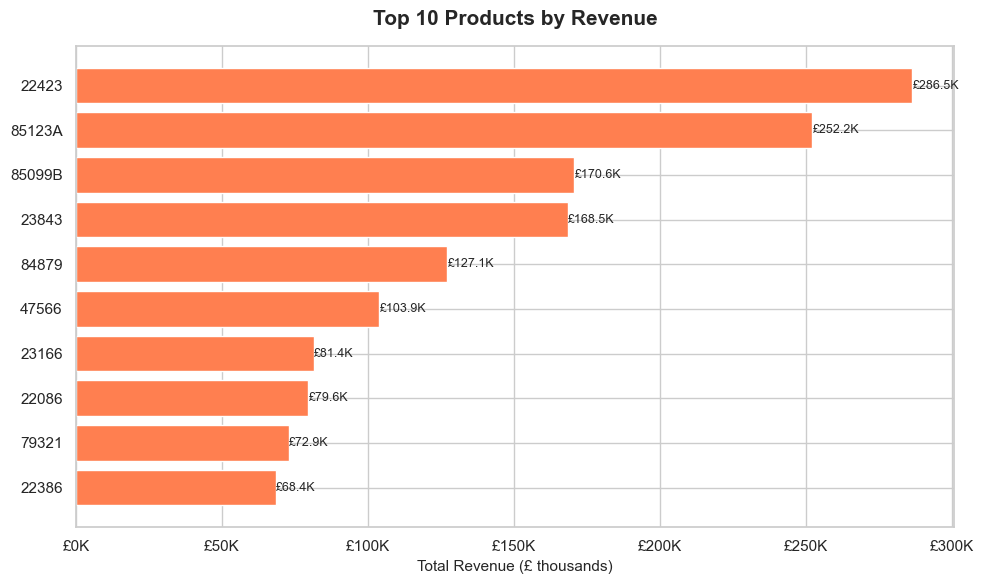

Chart 3 saved.


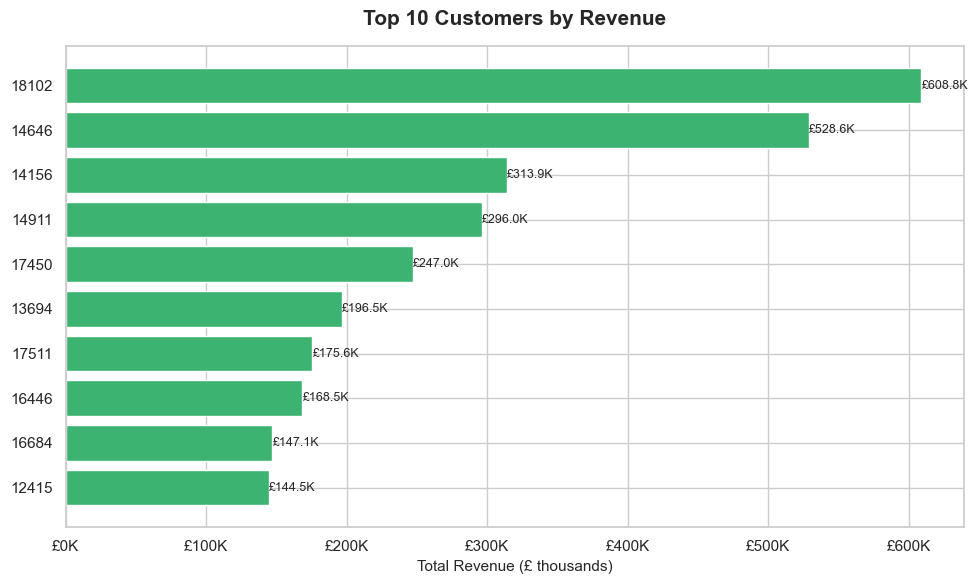

Chart 4 saved.


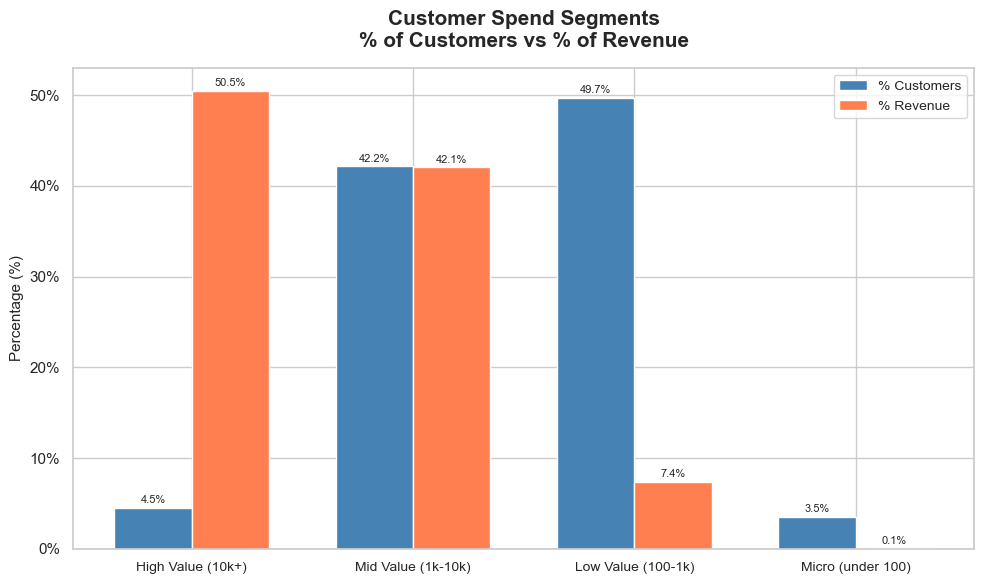

Chart 5 saved.


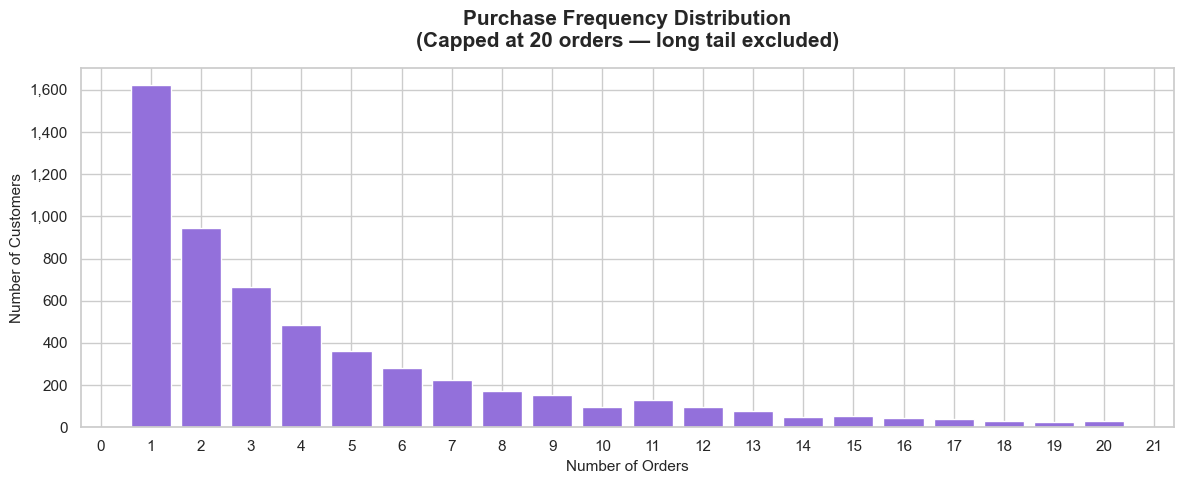

Chart 6 saved.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Global style ──────────────────────────────────────────────
sns.set_theme(style='whitegrid')
SAVE_PATH = 'outputs/'

# ── Load all files ────────────────────────────────────────────
revenue_df    = pd.read_csv('data/revenue_by_month.csv')
country_df    = pd.read_csv('data/country_wise_sales.csv')
stock_df      = pd.read_csv('data/stock_code_top10.csv')
customer_df   = pd.read_csv('data/top10_customer.csv')
segment_df    = pd.read_csv('data/spend_segment_info.csv')
frequency_df  = pd.read_csv('data/frequency_of_orders.csv')


# ═══════════════════════════════════════════════════════════════
# CHART 1 — Monthly Revenue Trend (Line Chart)
# ═══════════════════════════════════════════════════════════════
revenue_df['revenue_month'] = pd.to_datetime(revenue_df['revenue_month'])
revenue_df = revenue_df.sort_values('revenue_month')
revenue_df['month_label'] = revenue_df['revenue_month'].dt.strftime('%b %Y')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(revenue_df['month_label'], revenue_df['total_revenue'] / 1000,
        marker='o', linewidth=2, color='steelblue', markersize=5)

ax.set_title('Monthly Revenue Trend', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue (£ thousands)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}chart1_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")


# ═══════════════════════════════════════════════════════════════
# CHART 2 — Top 10 Countries by Revenue (Horizontal Bar)
# ═══════════════════════════════════════════════════════════════
# Exclude UK — it dominates and hides the others
country_filtered = country_df[country_df['country'] != 'United Kingdom'] \
                    .sort_values('total_revenue', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(country_filtered['country'], 
               country_filtered['total_revenue'] / 1000,
               color='steelblue', edgecolor='white')

ax.set_title('Top 10 Countries by Revenue (Excl. UK)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (£ thousands)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))

# Value labels on bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height() / 2,
            f'£{width:,.0f}K', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}chart2_country_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")


# ═══════════════════════════════════════════════════════════════
# CHART 3 — Top 10 Products by Revenue (Horizontal Bar)
# ═══════════════════════════════════════════════════════════════
stock_df = stock_df.sort_values('total_revenue', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(stock_df['stockcode'].astype(str),
               stock_df['total_revenue'] / 1000,
               color='coral', edgecolor='white')

ax.set_title('Top 10 Products by Revenue', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (£ thousands)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.2, bar.get_y() + bar.get_height() / 2,
            f'£{width:,.1f}K', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}chart3_top10_products.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")


# ═══════════════════════════════════════════════════════════════
# CHART 4 — Top 10 Customers by Revenue (Horizontal Bar)
# ═══════════════════════════════════════════════════════════════
customer_df = customer_df.sort_values('total_revenue', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(customer_df['customer_id'].astype(str),
               customer_df['total_revenue'] / 1000,
               color='mediumseagreen', edgecolor='white')

ax.set_title('Top 10 Customers by Revenue', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (£ thousands)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.2, bar.get_y() + bar.get_height() / 2,
            f'£{width:,.1f}K', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}chart4_top10_customers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved.")


# ═══════════════════════════════════════════════════════════════
# CHART 5 — Spend Segment (Double Bar: % Customers vs % Revenue)
# ═══════════════════════════════════════════════════════════════
segment_df = segment_df.sort_values('percent_revenue', ascending=False)

x = range(len(segment_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar([i - width/2 for i in x], segment_df['percent_customer'],
               width, label='% Customers', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], segment_df['percent_revenue'],
               width, label='% Revenue', color='coral')

ax.set_title('Customer Spend Segments\n% of Customers vs % of Revenue',
             fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xticks(list(x))
ax.set_xticklabels(segment_df['spend_segment'], fontsize=10)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}chart5_spend_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved.")


# ═══════════════════════════════════════════════════════════════
# CHART 6 — Purchase Frequency Distribution (Histogram-style Bar)
# ═══════════════════════════════════════════════════════════════
# Cap at 20 orders to avoid long tail squashing the chart
freq_capped = frequency_df[frequency_df['order_count'] <= 20].copy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(freq_capped['order_count'], freq_capped['num_customers'],
       color='mediumpurple', edgecolor='white')

ax.set_title('Purchase Frequency Distribution\n(Capped at 20 orders — long tail excluded)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Number of Orders', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}chart6_frequency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved.")

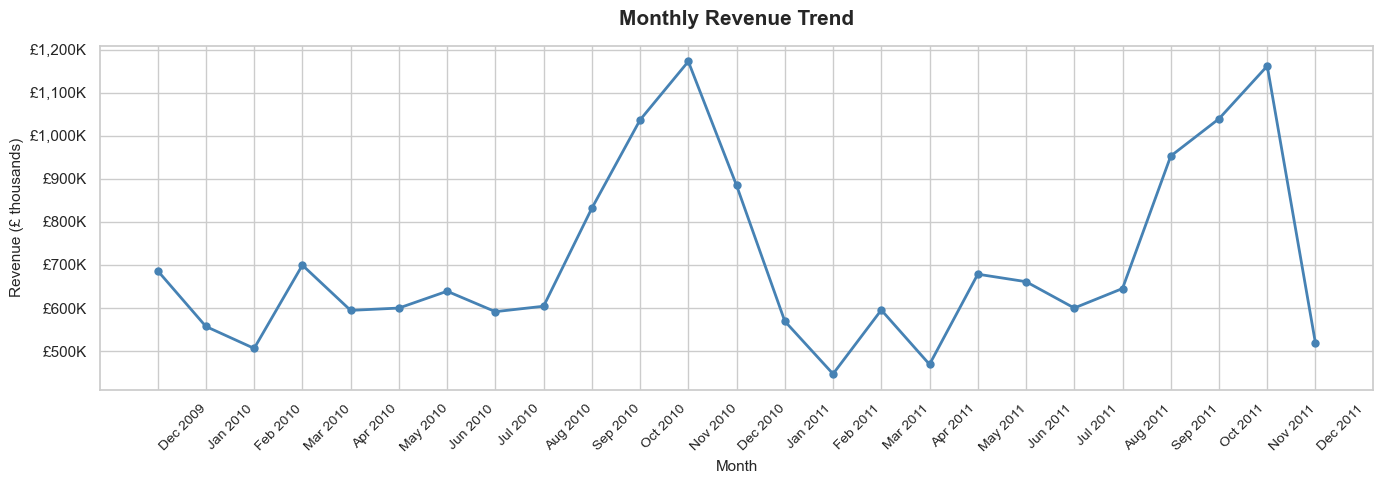

Chart 10 saved.


In [11]:
revenue_df['revenue_month'] = pd.to_datetime(revenue_df['revenue_month'])
revenue_df = revenue_df.sort_values('revenue_month')
revenue_df['month_label'] = revenue_df['revenue_month'].dt.strftime('%b %Y')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(revenue_df['month_label'], revenue_df['total_revenue'] / 1000,
        marker='o', linewidth=2, color='steelblue', markersize=5)

ax.set_title('Monthly Revenue Trend', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue (£ thousands)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))
plt.xticks(rotation=45, ha='left', fontsize=10)
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}chart10_monthly_revenue.png')
plt.show()
print("Chart 10 saved.")

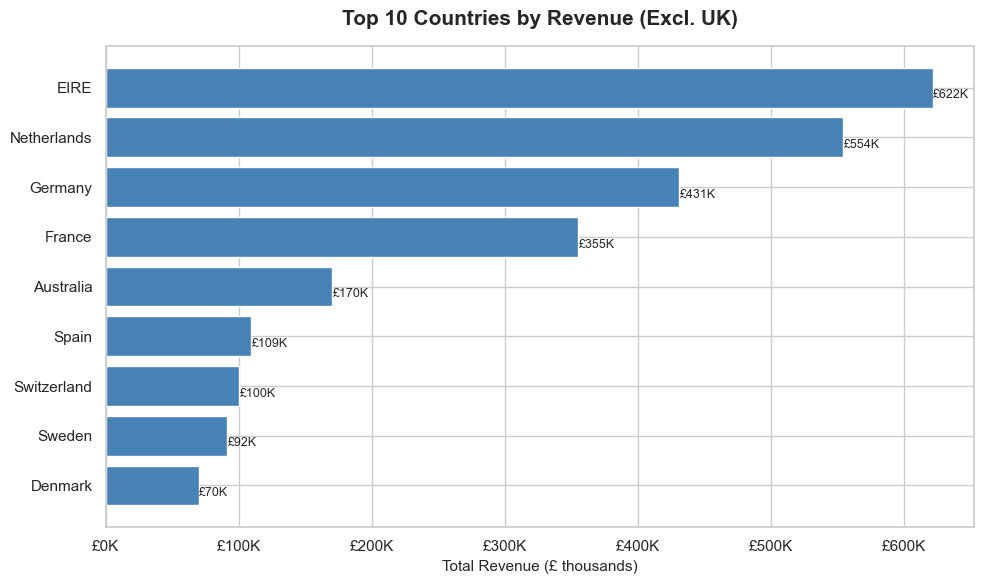

Chart 2 .


In [9]:
country_filtered = country_df[country_df['country'] != 'United Kingdom'] \
                    .sort_values('total_revenue', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(country_filtered['country'], 
               country_filtered['total_revenue'] / 1000,
               color='steelblue', edgecolor='white')

ax.set_title('Top 10 Countries by Revenue (Excl. UK)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (£ thousands)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))

# Value labels on bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + 0.245,
            f'£{width:,.0f}K', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print("Chart 2 .")

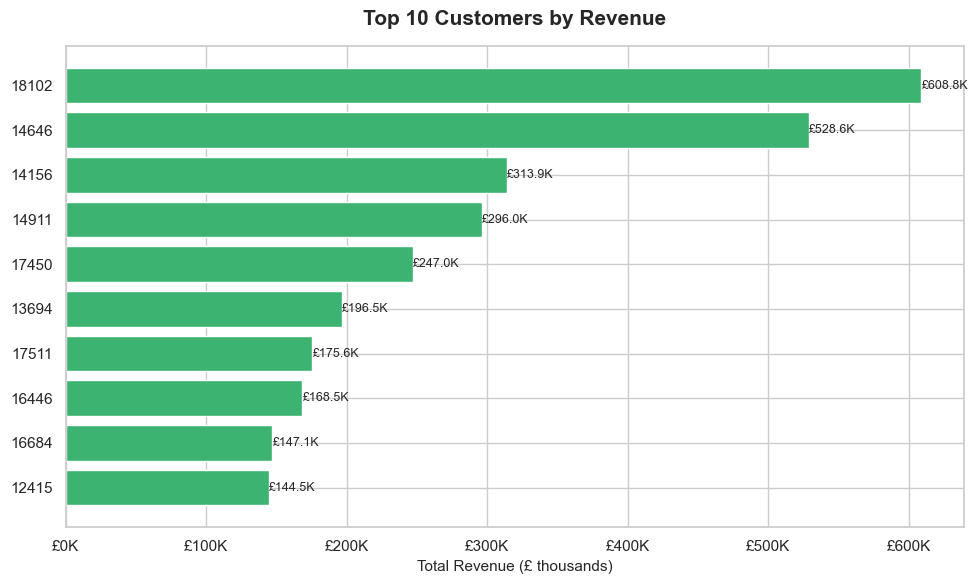

Chart 4 saved.


In [10]:
customer_df = customer_df.sort_values('total_revenue', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(customer_df['customer_id'].astype(str),
               customer_df['total_revenue'] / 1000,
               color='mediumseagreen', edgecolor='white')

ax.set_title('Top 10 Customers by Revenue', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (£ thousands)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.2, bar.get_y() + bar.get_height() / 2,
            f'£{width:,.1f}K', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print("Chart 4 saved.")

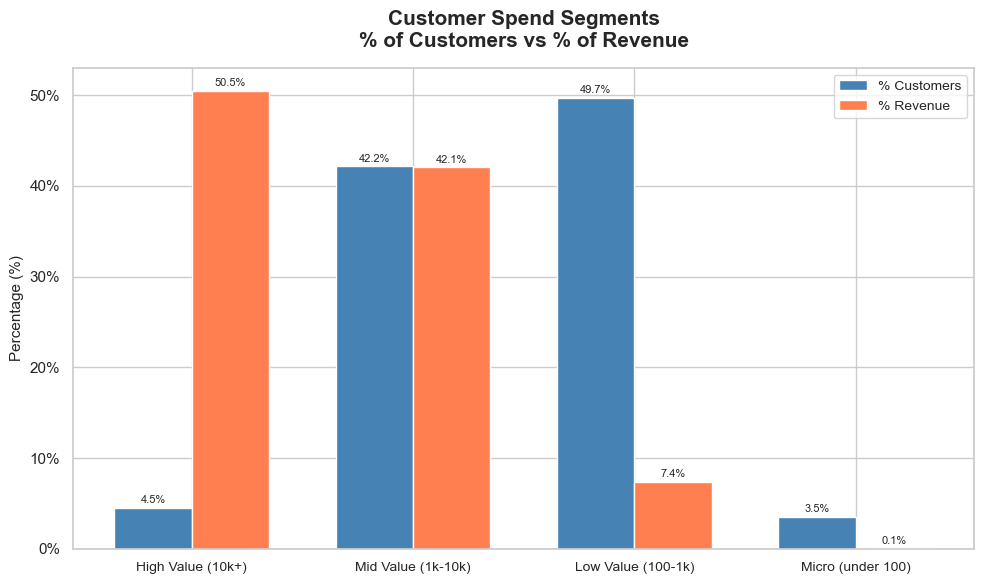

In [12]:
segment_df = segment_df.sort_values('percent_revenue', ascending=False)

x = range(len(segment_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar([i - width/2 for i in x], segment_df['percent_customer'],
               width, label='% Customers', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], segment_df['percent_revenue'],
               width, label='% Revenue', color='coral')

ax.set_title('Customer Spend Segments\n% of Customers vs % of Revenue',
             fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xticks(list(x))
ax.set_xticklabels(segment_df['spend_segment'], fontsize=10)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [3]:
!pip install XlsxWriter

In [4]:
import pandas as pd
import os

input_folder=r"C:\Users\hj161\OneDrive\Desktop\Coding\Customer_Cohort\data"

output_folder=r"C:\Users\hj161\OneDrive\Desktop\Coding\Customer_Cohort\data_workbook\AllCsvs_in_workbook.xlsx"
# Create a Pandas Excel writer using XlsxWriter as the engine
with pd.ExcelWriter(output_folder, engine='xlsxwriter') as writer:
    for filename in os.listdir(input_folder):
        if filename.endswith('.csv'):
            file_path = os.path.join(input_folder, filename)
            df = pd.read_csv(file_path)
            sheet_name = os.path.splitext(filename)[0][:31]  # Excel sheet name limit

            try :
                df.to_excel(writer, sheet_name=sheet_name, index=False)
            except Exception as e:
                print(f"Error occurred while processing {filename}: {e}")

print(f"All CSV files have been written to {output_folder}")

All CSV files have been written to C:\Users\hj161\OneDrive\Desktop\Coding\Customer_Cohort\data_workbook\AllCsvs_in_workbook.xlsx
